# Calibrated Explanations: LIME Plugin Example

This notebook demonstrates how to use the `official.explanation.factual.lime` plugin with the `calibrated-explanations` library.
The LIME plugin provides local interpretable model-agnostic explanations as part of the calibrated explanation flow.

In [30]:
import os

from calibrated_explanations import WrapCalibratedExplainer
from sklearn.datasets import make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Trust the LIME plugin for this session
os.environ["CE_TRUST_PLUGIN"] = "official.explanation.factual.lime"

## Setup Data and Model
We'll create a synthetic classification dataset and train a Random Forest model.

In [31]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_proper, X_calib, y_proper, y_calib = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

model = WrapCalibratedExplainer(RandomForestClassifier(n_estimators=100, random_state=42))
model.fit(X_proper, y_proper)

WrapCalibratedExplainer(learner=RandomForestClassifier(random_state=42), fitted=True, calibrated=False)

## Initialize Calibrated Explainer
Create a `CalibratedExplainer` and specify the LIME plugin.

In [32]:
model.calibrate(X_calib, y_calib)

WrapCalibratedExplainer(learner=RandomForestClassifier(random_state=42), fitted=True, calibrated=True, 
		explainer=CalibratedExplainer(mode=classification, learner=RandomForestClassifier(random_state=42)))

## Generate LIME Explanations
We use `explain_factual` with the LIME plugin.

Is 'lime' in batch_metadata? False


C:\Users\loftuw\Documents\Github\kristinebergs-calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\kristinebergs-calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()
C:\Users\loftuw\Documents\Github\kristinebergs-calibrated_explanations\src\calibrated_explanations\legacy\plotting.py:242: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


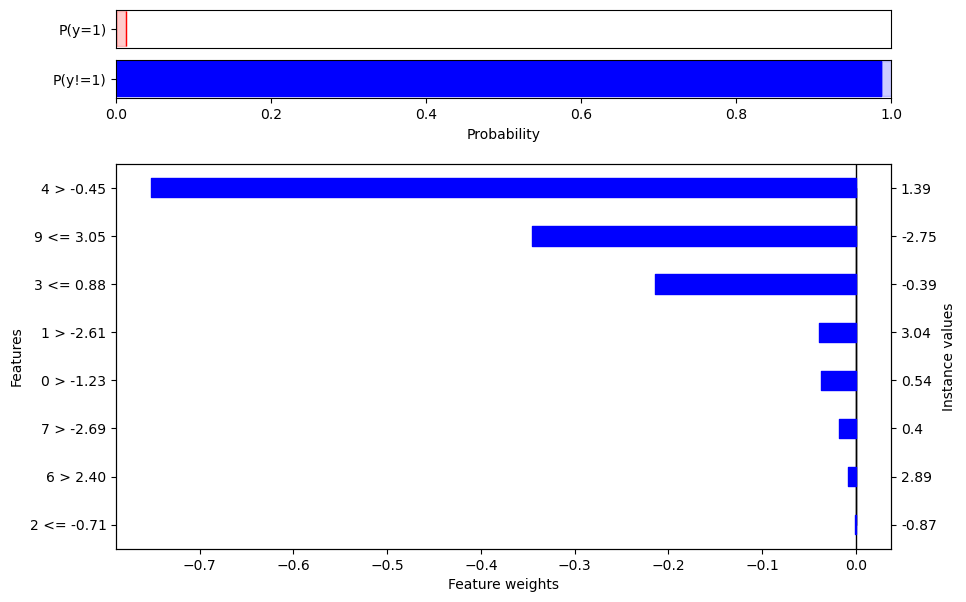

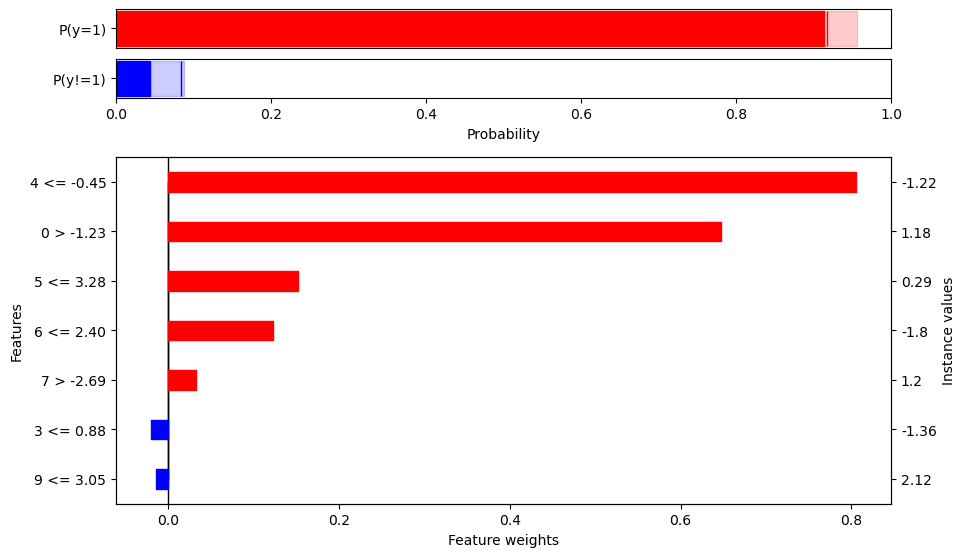

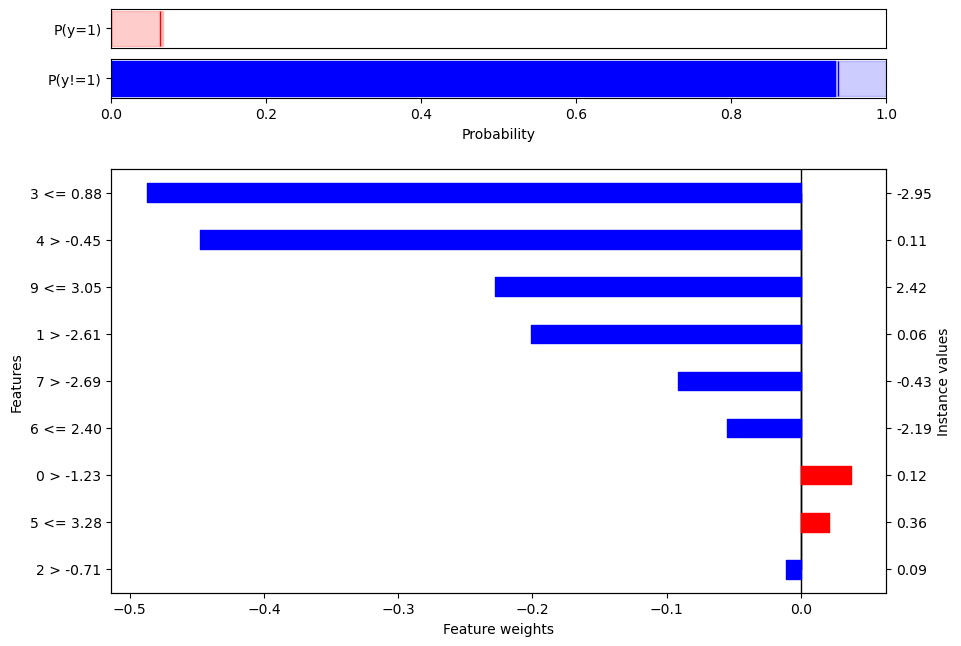

In [ ]:
# Select a few instances to explain
instances = X_test[:3]

# Generate factual explanations using the LIME plugin
# The plugin is identified by its name 'official.explanation.factual.lime'
explanations = model.explain_factual(instances, plugin="official.explanation.factual.lime")

# Verify if we have the Lime batch metadata
print(f"Is 'lime' in batch_metadata? {'lime' in explanations.batch_metadata}")

# Display the explanations
explanations.plot(uncertainty=True)